This notebook validates the Finite Element formulation against the analytical results of cantiliever beam.
Please read Readme on the link mentioned below for more details

Author: Kaushik S

https://github.com/Kaaaizoku/Modal_Rattle_Analysis

In [2]:
#Importing the relevant libraries
import numpy as np
import sympy as sp
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [41]:
#initialising constants and variables
t = sp.symbols('t')
L = 1
x = sp.symbols('x')
b1 = 1.875 #beta_n values are standard for L=1 
b2 = 4.694
b3 = 7.855
E= 200E9
I = 8.334e-6
rhol = 78

# Analytical formulation

The mode shape of Cantilever beam is given by
$$
\phi_n(x)
=
\cosh(\beta_n x)
-
\cos(\beta_n x)
-
\sigma_n
\left[
\sinh(\beta_n x)
-
\sin(\beta_n x)
\right]
$$

where

$$
\sigma_n
=
\frac{
\cosh(\beta_n L)+\cos(\beta_n L)
}{
\sinh(\beta_n L)+\sin(\beta_n L)
}.
$$

In [4]:
#Initialising the standard shape function of cantilever beam
sigma1 = (sp.cosh(b1*L) + sp.cos(b1*L))/(sp.sinh(b1*L) + sp.sin(b1*L))
sigma2 = (sp.cosh(b2*L) + sp.cos(b2*L))/(sp.sinh(b2*L) + sp.sin(b2*L))
sigma3 = (sp.cosh(b3*L) + sp.cos(b3*L))/(sp.sinh(b3*L) + sp.sin(b3*L))

phi1 = sp.cosh(b1*x) - sp.cos(b1*x) - sigma1*(sp.sinh(b1*x) - sp.sin(b1*x))
phi2 = sp.cosh(b2*x) - sp.cos(b2*x) - sigma2*(sp.sinh(b2*x) - sp.sin(b2*x))
phi3 = sp.cosh(b3*x) - sp.cos(b3*x) - sigma3*(sp.sinh(b3*x) - sp.sin(b3*x))

In [5]:
#calculating the first three natural frequencies of Cantilever beam
omega1 = ((b1*L)**2)*np.sqrt(E*I/(rhol*L**4))
omega2 = ((b2*L)**2)*np.sqrt(E*I/(rhol*L**4))
omega3 = ((b3*L)**2)*np.sqrt(E*I/(rhol*L**4))

The equation to be solved (in modal coordinates)
$$
\ddot{\boldsymbol{\eta}}(t)
+
\boldsymbol{\Omega}^2\boldsymbol{\eta}(t)
=
-\boldsymbol{\Gamma}\ a_b(t),
$$

$$
{
\Gamma_n
=
\frac{
\displaystyle \int_0^L \phi_n(x)\,dx
}{
\displaystyle \int_0^L \phi_n^2(x)\,dx
}
}
$$



In [6]:
#base acceleration
a_b = 10*sp.sin(5*t)

In [7]:
gamma1 = sp.integrate(phi1, (x, 0, L))/sp.integrate(phi1**2, (x, 0, L))
gamma2 = sp.integrate(phi2, (x, 0, L))/sp.integrate(phi2**2, (x, 0, L))
gamma3 = sp.integrate(phi3, (x, 0, L))/sp.integrate(phi3**2, (x, 0, L))

$$
{
\eta_n(t)
=
a_0\frac{\Gamma_n}{\omega_n^2-\Omega^2}
\left[
\frac{\Omega}{\omega_n}\sin(\omega_n t)
-
\sin(\Omega t)
\right]
}
$$

$$
\Omega \neq \omega_n.
$$

In [9]:
eta1_sol = 10*(gamma1/(omega1**2-25))*((5/omega1)*sp.sin(omega1*t)-sp.sin(5*t))
eta2_sol = 10*(gamma2/(omega2**2-25))*((5/omega2)*sp.sin(omega2*t)-sp.sin(5*t))
eta3_sol = 10*(gamma3/(omega3**2-25))*((5/omega3)*sp.sin(omega3*t)-sp.sin(5*t))

Text(0.5, 1.0, 'cantilever response using analytical formulation')

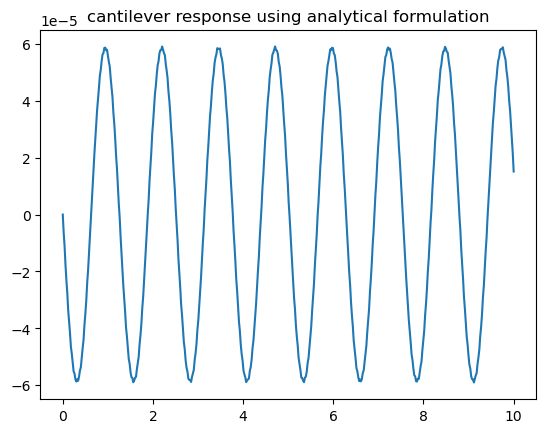

In [44]:
w = phi1*eta1_sol + phi2*eta2_sol + phi3*eta3_sol
w_t = w.subs(x,L)

func_wt = sp.lambdify(t, w_t, modules="numpy")
t_np = np.linspace(0,10,500)
plt.plot(t_np, func_wt(t_np))
plt.title("cantilever response using analytical formulation")

# Finite Element formulation

In [15]:
def beam_element_stiffness(E, I, Le):
    """
    Euler-Bernoulli beam element stiffness matrix.
    DOF ordering: [w1, theta1, w2, theta2]
    """
    return (E * I / Le**3) * np.array([
        [12,        6*Le,       -12,        6*Le],
        [6*Le,      4*Le**2,     -6*Le,      2*Le**2],
        [-12,       -6*Le,       12,        -6*Le],
        [6*Le,      2*Le**2,     -6*Le,      4*Le**2]
    ])

In [16]:
def beam_element_mass(rho, A, Le):
    """
    Consistent mass matrix for an Euler-Bernoulli beam element.
    DOF ordering:[w1, theta1, w2, theta2]
    """
    return (rho * A * Le / 420) * np.array([
        [156,          22*Le,       54,         -13*Le],
        [22*Le,        4*Le**2,     13*Le,       -3*Le**2],
        [54,           13*Le,       156,         -22*Le],
        [-13*Le,      -3*Le**2,    -22*Le,        4*Le**2]
    ])

In [ ]:
#initialising the constants
E1 = 200E9
Le1 = 1
A1 = 1e-2
I1 = 8.334e-6
rho1 = 7800

In [ ]:
#initialising the stiffness and mass matrix, no assembly needed, since it is only a single element
K1 = beam_element_stiffness(E1, I1, Le1)
M1 = beam_element_mass(rho1, A1, Le1)

In [45]:
#Transformation matrix to constraint the DOFs the are fixed for extracting the eigen vectors
T = np.array([
    [0,0],
    [0,0],
    [1,0],
    [0,1]
])

K_constrained = T.T@K1@T
M_constrained = T.T@M1@T

eigenvalues, eigenvectors_reduced = eigh(
    K_constrained,
    M_constrained)

eigenvectors_full = T@eigenvectors_reduced

In [46]:
#hermite shape_functions - only for L=1

N1 = lambda x,L: 1 - 3*(x/L)**2 + 2*(x/L)**3
N2 = lambda x,L: (x - 2*x**2 + x**3)
N3 = lambda x,L: 3*(x/L)**2 - 2*(x/L)**3
N4 = lambda x,L: -x**2 + x**3

shape_function = lambda x, L: np.array([N1(x, L), N2(x, L), N3(x, L), N4(x, L)])

Text(0.5, 1.0, 'Mode shapes')

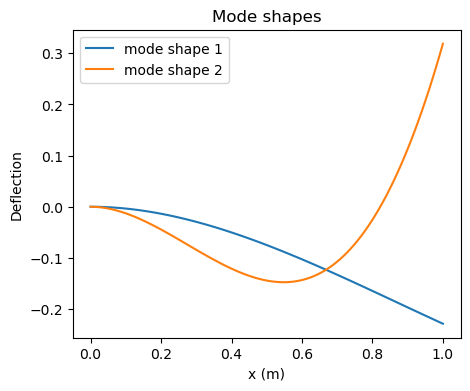

In [47]:
plt.figure(figsize=(5,4))
for i, mode in enumerate(eigenvectors_full.T):
    phi_1 = mode[0:4]
    phi_2 = mode[4:8]

    x = np.linspace(0,Le1, 100)

    w1 = shape_function(x, Le1).T@phi_1

    plt.plot(x,w1, label=f"mode shape {i+1}")
    plt.legend()

plt.xlabel("x (m)")
plt.ylabel("Deflection")
plt.title("Mode shapes")

#### Implicit RK4 method used for time stepping

In [ ]:
# initialising the variables needed for IRK4 
Lambda = np.diag(eigenvalues)
O = np.zeros_like(Lambda)
I1 = np.eye(Lambda.shape[1])
A = np.block([[O, -Lambda],[I1, O]])
Gamma = -eigenvectors_full.T@M1

In [ ]:
# function returns the base acceleration
def f(t):
    d2ydt2 = 10*np.sin(5*t)
    Yddot = np.array([d2ydt2,0,d2ydt2,0])
    return np.block([Gamma@Yddot, np.zeros(2)])

In [61]:
I2 = np.eye(4)
a11 = 1/4
a12 = (1/4)-(np.sqrt(3)/6)
a21 = (1/4)+(np.sqrt(3)/6)
a22 = 1/4
c1 = (1/2)-(np.sqrt(3)/6)
c2 = (1/2)+(np.sqrt(3)/6)
b1 = 1/2
b2 = 1/2
h = 0.01

G = np.block([[I2-a11*h*A, -a12*h*A],[-a21*h*A, I2-a22*h*A]])
G_inv = np.linalg.inv(G)

In [57]:
def IRK_step(z_n, t_n):
    f1 = f(t_n + c1*h)
    #print(f"f1: {f1.shape}")
    f2 = f(t_n + c2*h)
    Azn = A@z_n
    #print(f"Azn {Azn.shape}")

    R = np.block([Azn + f1 , Azn + f2])
    #print(f"R {R.shape}")
    S = h/2*np.block([I2 , I2])
    #print(f"S {S.shape}")
    return z_n + S@G_inv@R

In [58]:
z0 = np.zeros((4)) # initial condtions, w(0) = 0, v(0) = 0
end_time = 10
n_iter = int(10/h)
zn = z0
tn = 0
eta = np.zeros((2, n_iter+1), dtype= np.float32)
for i in range(n_iter+1):
    eta[:, i] = zn[2:]

    if i < n_iter:
        zn = IRK_step(zn, tn)
        tn += h

Text(0.5, 1.0, 'Comparison of anlaytical and FE modal transient results for base excitation')

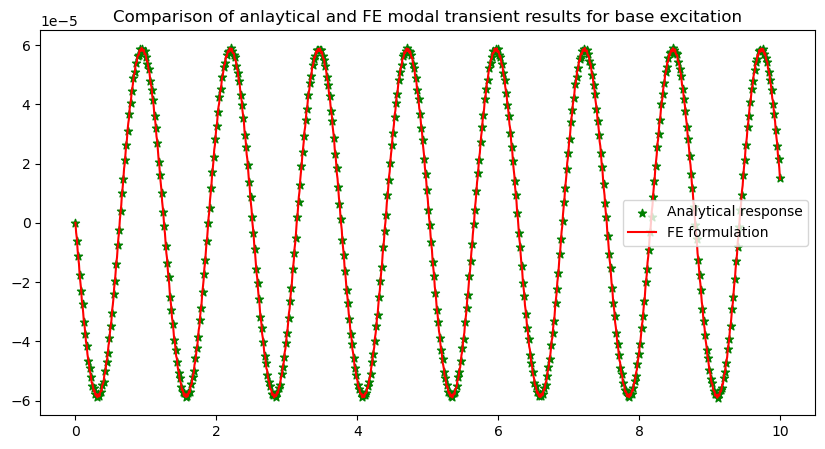

In [60]:
x_ts = eigenvectors_full@eta

w_end1 = x_ts[2,:]
t_plot = np.linspace(0,10,1001)

plt.figure(figsize=(10,5))
plt.scatter(t_np, func_wt(t_np), color = "green", marker='*', label = "Analytical response")
plt.plot(t_plot, w_end1, color = 'red', label="FE formulation")
plt.legend()
plt.title("Comparison of anlaytical and FE modal transient results for base excitation")